<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_0_Classification_Foundations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification: Part 1
## Foundations

**Author:** Brad Sheese

---

### Learning Objectives
In this first notebook, we will establish the foundations of classification by exploring:
1. How to identify and visualize class imbalance.
2. Why accuracy is often a trap in classification.
3. How to train an XGBoost model and interpret its feature importance.
4. The difference between hard predictions (labels) and soft predictions (probabilities).

## Regression vs. Classification

Up to this point, we have used linear regression to predict continuous numbers (like House Prices). However, many real-world problems ask a binary question: *Will this customer default on their loan?* (Yes/No), *Is this email spam?* (Yes/No), *Is this tumor malignant?* (Yes/No).

The transition from regression to classification represents a fundamental shift in the nature of the target variable. While regression aims to map inputs to a continuous scalar value, classification seeks to assign inputs to discrete, categorical labels.

The linear regression framework we've gotten used to breaks down when we try to apply it classification tasks. To address these issues, we must move beyond linear trends and adopt models that utilize non-linear activation functions to map real-valued inputs into the probabilistic domain.


## Section 1: Load and Examine the Data

We will be using the South German Credit dataset. Our goal is to predict whether a loan applicant is a "good" or "bad" credit risk based on features like their checking account status, credit history, and employment duration.

**Data Source:** https://archive.ics.uci.edu/dataset/522/south+german+credit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Load the Credit Card Default dataset from OpenML
from sklearn.datasets import fetch_openml

print('Loading dataset...')
data = fetch_openml(name='credit-g', version=1, as_frame=True)
df = data.frame

print(f'Dataset shape: {df.shape}')
df.head()

Loading dataset...
Dataset shape: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


### Examine the Dataframe

Notice the mix of numerical and categorical columns. Just like in our Regression notebooks, we will need to handle these differently.

Look closely at the `class` column. This is our target variable. It contains labels 'good' and 'bad'.

## Section 2: The Accuracy Paradox and Class Imbalance

One of the most important concepts in classification is class distribution. In many real-world scenarios (like fraud or rare diseases), the classes are not 50/50.

If 99% of people do not have a rare disease, a "dumb" model that simply predicts "No Disease" for every single person will be 99% accurate. However, it is a completely useless model because it fails to catch the very thing we care about (the 1%). This is known as the accuracy paradox.

Let's see how imbalanced our credit dataset is.

Target variable distribution:
class
good    0.7
bad     0.3
Name: proportion, dtype: float64


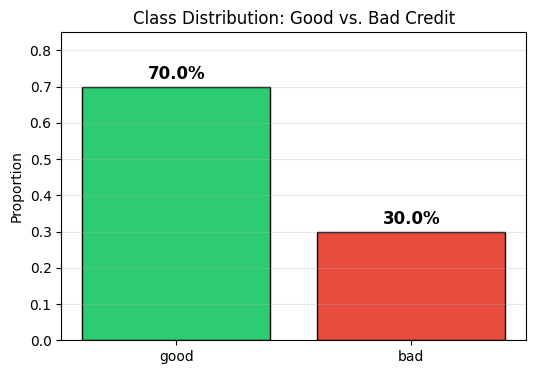


Naive baseline accuracy (always predict 'Good'): 70.0%
Any useful model must significantly exceed this baseline.


In [2]:
# Check target variable distribution
class_counts = df['class'].value_counts(normalize=True)
print('Target variable distribution:')
print(class_counts)

# Visualize
plt.figure(figsize=(6, 4))
bars = plt.bar(class_counts.index, class_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
for bar, val in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{val:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylabel('Proportion')
plt.title('Class Distribution: Good vs. Bad Credit')
plt.ylim(0, 0.85)
plt.grid(axis='y', alpha=0.3)
plt.show()

baseline = (df['class'] == 'good').mean()
print(f"\nNaive baseline accuracy (always predict 'Good'): {baseline:.1%}")
print("Any useful model must significantly exceed this baseline.")

### Understanding the Baseline

70% of our samples are 'Good'. This means that if we built a model that did nothing but guess 'Good' for every customer, we would achieve 70% accuracy.

As you move through these notebooks, always remember: If your model's accuracy isn't significantly better than the majority class percentage, your model hasn't learned anything useful.

## Section 3: Preparing the Data for XGBoost

To train our model, we must perform several cleaning steps:

1. Binary encoding: Convert our target ('good'/'bad') into numbers (0 and 1). XGBoost requires numeric targets.
2. One-hot encoding: Convert categorical text columns (like 'employment') into multiple binary numeric columns. The model can't process text.
3. Stratified split: Ensure that our training and testing sets have the same 70/30 ratio of 'good' vs 'bad' cases. Without stratification, a random split might accidentally give us a test set that's 90% 'good', making evaluation misleading.

Note on feature scaling: Unlike linear models (like logistic regression), tree-based models like XGBoost are not sensitive to feature scale. They make decisions based on threshold splits, so the absolute magnitude of features doesn't affect the model. We skip the scaling step.

In [3]:
# 1. Convert target to binary: good = 0 (Normal), bad = 1 (Event of interest/Default)
y = (df["class"] == "bad").astype(int)
X = df.drop(columns=["class"])

# 2. Identify and encode categorical features
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Clean column names for XGBoost compatibility
import re
X_encoded.columns = [re.sub(r"[<>[\]]", "_", col) for col in X_encoded.columns]

# 3. Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Original features: {X.shape[1]}")
print(f"Encoded features: {X_encoded.shape[1]}")
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set class ratio: {y_test.mean():.1%} bad, {(1-y_test.mean()):.1%} good")


Original features: 20
Encoded features: 48
Training set size: 700
Test set class ratio: 30.0% bad, 70.0% good


## Section 4: Training the XGBoost Model

### How the Model Learns: Gradient Boosting

XGBoost (eXtreme Gradient Boosting) is a powerful tree-based ensemble algorithm. Instead of fitting a single model, it builds an ensemble of decision trees sequentially, where each new tree corrects the errors of the previous ones.

The algorithm works by:
1. Starting with an initial prediction (usually the mean probability)
2. Calculating the "gradient" (error) of the current predictions
3. Fitting a new decision tree to reduce this gradient
4. Adding this tree to the ensemble (with a learning rate)
5. Repeating for a specified number of trees

### Class Weighting

Because we have an imbalanced dataset (70/30), we will use the parameter `scale_pos_weight`. This ratio tells the model to "pay more attention" to the minority class (the defaults). It is calculated as: (number of negatives) / (number of positives) = 700/300 ≈ 2.33.

In [4]:
# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Instantiate and train the XGBoost model
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
)
model.fit(X_train, y_train)

print('Model training complete.')

Model training complete.


## Section 5: Interpreting Model Internals: Feature Importance

Unlike linear models where coefficients tell us the direction and magnitude of each feature's effect, tree-based models like XGBoost provide feature importance scores. These scores represent how much each feature contributes to reducing the model's loss function (improving predictions).

### How Feature Importance Works in XGBoost

XGBoost calculates importance based on:
- Gain: How much each feature contributes to reducing the loss when making splits
- Cover: How many samples are affected by splits on that feature
- Frequency: How often a feature is used in trees

- A higher importance score means the feature had a larger impact on the model's predictions
- These are relative scores — they sum to 1 (or 100%)
- Unlike log-odds coefficients, these don't tell us the *direction* of the effect (positive vs negative)
- The visualization shows both the strongest drivers (high importance) and least important features


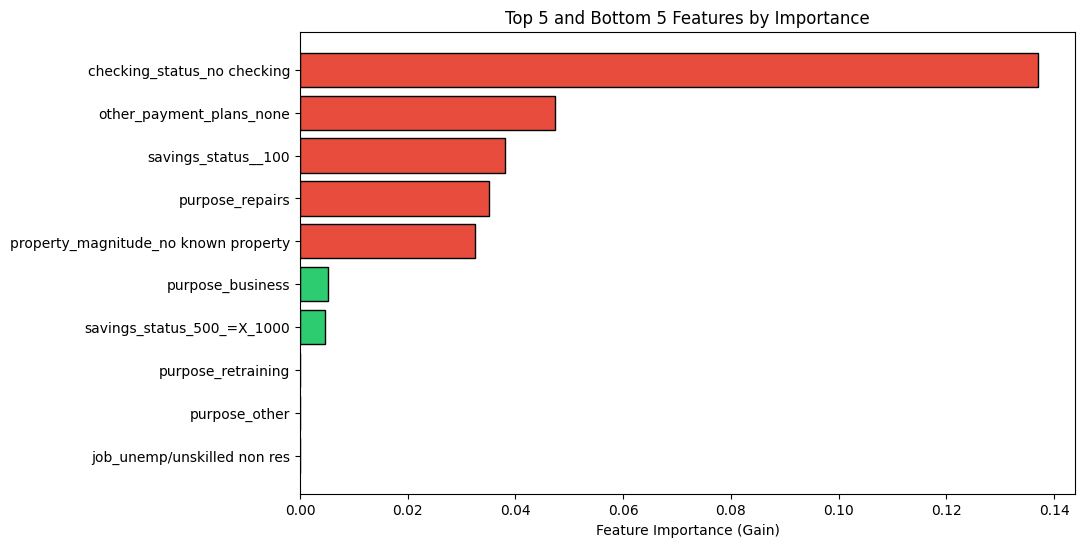


Top 3 Most Important Features:
  checking_status_no checking         Importance: 0.1370
  other_payment_plans_none            Importance: 0.0473
  savings_status__100                 Importance: 0.0381

Bottom 3 Least Important Features:
  purpose_retraining                  Importance: 0.0000
  purpose_other                       Importance: 0.0000
  job_unemp/unskilled non res         Importance: 0.0000


In [5]:
# Extract feature importance
importance_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

# Visualize the top and bottom features by importance
plt.figure(figsize=(10, 6))
top_and_bottom = pd.concat([importance_df.head(5), importance_df.tail(5)])
colors = ['#e74c3c' if imp >= importance_df['Importance'].median() else '#2ecc71' for imp in top_and_bottom['Importance']]

plt.barh(top_and_bottom['Feature'], top_and_bottom['Importance'], color=colors, edgecolor='black')
plt.xlabel('Feature Importance (Gain)')
plt.title('Top 5 and Bottom 5 Features by Importance')
plt.gca().invert_yaxis()
plt.show()

# Show top 3 with importance scores
print("\nTop 3 Most Important Features:")
for _, row in importance_df.head(3).iterrows():
    print(f"  {row['Feature']:<35} Importance: {row['Importance']:.4f}")

# Show bottom 3
print("\nBottom 3 Least Important Features:")
for _, row in importance_df.tail(3).iterrows():
    print(f"  {row['Feature']:<35} Importance: {row['Importance']:.4f}")

### Interpreting the Results

The chart shows the top 5 most important features (red bars) and the bottom 5 least important features (green bars). These importance scores are calculated based on how much each feature contributes to reducing the model's loss (improving predictions).

Important: Unlike logistic regression coefficients, feature importance doesn't tell us the *direction* of the effect (positive vs negative). A high importance score means the feature matters a lot to the model, but we need to dig deeper to understand whether it increases or decreases default risk.

To understand the direction of effects, we would need to examine partial dependence plots or analyze how predictions change when we vary individual features. For now, focus on which features the model finds most informative.


## Section 6: Probabilities and the Decision Threshold

When we ask a model to `.predict()`, it gives us a hard prediction (a 0 or a 1). But inside the model, it actually calculates a soft prediction (a probability between 0 and 1).

By default, sklearn uses a threshold of 0.5:
- If $P(Default) \ge 0.5$, predict 1.
- If $P(Default) < 0.5$, predict 0.

Let's visualize how these probabilities are distributed for our test set.

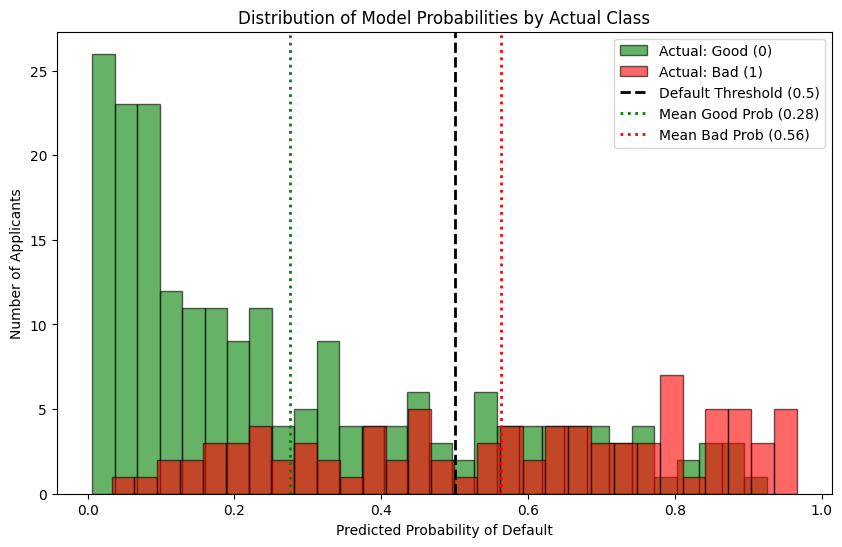


Overlap Analysis:
  41.1% of actual defaulters scored below 0.5 (missed cases / false negatives)
  21.0% of good customers scored above 0.5 (false alarms / false positives)


In [6]:
# Get probabilities for the positive class (Default)
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)# Calculate overlap statistics
fn_rate = ((y_proba[y_test==1] < 0.5).sum() / (y_test==1).sum()) * 100
fp_rate = ((y_proba[y_test==0] >= 0.5).sum() / (y_test==0).sum()) * 100

fig, ax = plt.subplots(figsize=(10, 6))

# Plot overlapping histograms by actual class
ax.hist(y_proba[y_test==0], bins=30, alpha=0.6, label='Actual: Good (0)', color='green', edgecolor='black')
ax.hist(y_proba[y_test==1], bins=30, alpha=0.6, label='Actual: Bad (1)', color='red', edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Default Threshold (0.5)')

# Add mean probability lines
mean_good = y_proba[y_test==0].mean()
mean_bad = y_proba[y_test==1].mean()
ax.axvline(x=mean_good, color='green', linestyle=':', linewidth=2, label=f'Mean Good Prob ({mean_good:.2f})')
ax.axvline(x=mean_bad, color='red', linestyle=':', linewidth=2, label=f'Mean Bad Prob ({mean_bad:.2f})')

ax.set_xlabel('Predicted Probability of Default')
ax.set_ylabel('Number of Applicants')
ax.set_title('Distribution of Model Probabilities by Actual Class')
ax.legend()
plt.show()

print(f"\nOverlap Analysis:")
print(f"  {fn_rate:.1f}% of actual defaulters scored below 0.5 (missed cases / false negatives)")
print(f"  {fp_rate:.1f}% of good customers scored above 0.5 (false alarms / false positives)")

### Reading the Probability Distribution

- The green distribution (actual good customers) is shifted left — the model generally assigns them low default probabilities.
- The red distribution (actual defaulters) is shifted right — the model generally assigns them higher default probabilities.
- The dotted lines show the mean probability for each class. The further apart these are, the better the model is at separating the two groups.
- The overlap around the 0.5 threshold is where the model is uncertain. The percentages printed above quantify this: 41.1% of actual defaulters were missed, and 21.0% of good customers were falsely flagged.

In Notebook 3, we will learn how to move that 0.5 line to better suit our business needs.

## Section 7: Basic Model Evaluation

Before we dive into the confusion matrix in Part 2, let's check the model's basic accuracy and compare it to our naive baseline.

In [7]:
accuracy = model.score(X_test, y_test)
baseline = (y_test == 0).mean()

print(f"Model Accuracy:      {accuracy:.1%}")
print(f"Naive Baseline:      {baseline:.1%}")
print(f"Improvement:         {(accuracy - baseline):.1%} above baseline")

if accuracy > baseline:
    print(f"\nOur model is {(accuracy/baseline - 1)*100:.0f}% better than always guessing 'Good'.")
else:
    print("\nWarning: The model is not beating the naive baseline.")

Model Accuracy:      73.0%
Naive Baseline:      70.0%
Improvement:         3.0% above baseline

Our model is 4% better than always guessing 'Good'.


## Conclusion

In this notebook, we've moved from the world of continuous prediction to the world of classification. Key takeaways:

1. XGBoost is a powerful tree-based ensemble that builds multiple decision trees sequentially, with each tree correcting the errors of the previous ones.
2. Class imbalance makes accuracy a potentially deceptive metric — always compare against the naive baseline.
3. Feature importance tells us which features matter most to the model, but not the direction of the effect (positive vs negative).
4. Probabilities vs. hard predictions — the model calculates a probability for every applicant; the 0.5 threshold converts this to a yes/no decision. The overlap between the two class distributions shows where the model is uncertain.

In the next notebook, we will dive deeper into model evaluation using the confusion matrix to see exactly where our model is making mistakes, and learn about precision, recall, and the f1-score.